# 008. デコーディング戦略(Decoding Strategies)

## 1. 概要 / Overview

自己回帰言語モデル(006・007 でスクラッチ実装した `GPTLanguageModel`)は、各ステップで次トークンの確率分布 $P(x_t \mid x_{<t})$ を出力するのみであり、その分布から実際にどのトークン列を生成するかは **デコーディング戦略(decoding strategy)** に委ねられる。本トピックでは、`GPTLanguageModel.generate()` が既に対応する貪欲法(greedy decoding)・temperature サンプリングに加え、top-k サンプリング・top-p サンプリング(nucleus sampling)・ビームサーチ(beam search)をスクラッチ実装し、生成されるテキストの性質(繰り返しの多さ・多様性・尤度)がデコーディング戦略によってどう変わるかを比較する。

比較には 006(小型 GPT の事前学習)・007(学習の安定化)で確立したアーキテクチャ・学習設定を用いて英語の小型 GPT モデルを新たに学習し、そのモデルを Hugging Face Hub に公開する(将来の他トピックで再利用する「標準モデル」の位置づけ)。

## 2. 参考論文 / References

- Fan, A., Lewis, M., Dauphin, Y., "Hierarchical Neural Story Generation", ACL 2018.
  https://arxiv.org/abs/1805.04833(top-k サンプリング)
- Holtzman, A., Buys, J., Du, L., Forbes, M., Choi, Y., "The Curious Case of Neural Text
  Degeneration", ICLR 2020. https://arxiv.org/abs/1904.09751(top-p サンプリング / nucleus
  sampling、退化現象(Degeneration)の理論)
- Wu, Y. et al., "Google's Neural Machine Translation System: Bridging the Gap between Human
  and Machine Translation", 2016. https://arxiv.org/abs/1609.08144(長さペナルティ付き
  ビームサーチ)
- Li, J., Galley, M., Brockett, C., Gao, J., Dolan, B., "A Diversity-Promoting Objective
  Function for Neural Conversation Models", NAACL 2016. https://arxiv.org/abs/1510.03055
  (distinct-n、多様性指標)
- Welleck, S. et al., "Neural Text Generation with Unlikelihood Training", ICLR 2020.
  https://arxiv.org/abs/1908.04319(seq-rep-n、n-gram 重複率)

本トピックのモデル学習は、006・007 の以下の論文にも依拠する(理論の再掲はしない)。

- Radford, A. et al., "Language Models are Unsupervised Multitask Learners", 2019(GPT-2、
  バイトレベル BPE)
- Su, J. et al., "RoFormer: Enhanced Transformer with Rotary Position Embedding", 2021(RoPE)
- Loshchilov, I., Hutter, F., "Decoupled Weight Decay Regularization", ICLR 2019(AdamW)

## 3. 理論 / Theory

### 3.1 デコーディング戦略の位置づけ

自己回帰言語モデルは、系列 $x_{1:t-1}$ が与えられたとき次トークンの条件付き分布

$$
P(x_t \mid x_{1:t-1}) = \mathrm{softmax}(\mathrm{logits}_t)
$$

を出力する(`GPTLanguageModel.forward` の `logits`)。系列全体の生成は、この分布から
逐次的にトークンを選び、選んだトークンを文脈に追加して次のステップへ進める操作を
繰り返すことで行う。**モデルが学習するのは分布 $P$ のみであり、この分布から実際に
どのトークンを選ぶか(デコーディング戦略)はモデルの学習とは独立な、生成時の設計
判断である。** 同一のモデル・同一の分布からでも、デコーディング戦略が異なれば
生成されるテキストの性質(流暢さ・多様性・繰り返しの多さ)は大きく異なりうる。

以下、$V$ を語彙サイズ(vocabulary size)、$\mathrm{logits}_t \in \mathbb{R}^V$ を
ステップ $t$ の出力(`GPTLanguageModel.forward` の最終次元)とする。

### 3.2 貪欲法(Greedy Decoding)と temperature サンプリング(復習)

**貪欲法**: 各ステップで確率最大のトークンを決定的に選ぶ。

$$
x_t = \arg\max_{v} P(v \mid x_{<t})
$$

**temperature サンプリング**: 分布を温度 $T$ でスケーリングしてから多項分布サンプリングする。

$$
P_T(v \mid x_{<t}) = \frac{\exp(\mathrm{logits}_t[v] / T)}{\sum_{v'} \exp(\mathrm{logits}_t[v'] / T)}
$$

$T \to 0$ で貪欲法に一致し(最大値以外の項が相対的に無視できるほど小さくなる)、
$T=1$ で元の分布からのサンプリング、$T \to \infty$ で一様分布に近づく。いずれも
`GPTLanguageModel.generate()`(006)に実装済みである。

### 3.3 top-k サンプリング

Fan et al., 2018 が提案した手法。各ステップで確率上位 $k$ 個のトークンのみを候補集合
とし、それ以外の確率を 0 にしたうえで再正規化してサンプリングする。

$$
V^{(k)}_t = \{\, v \mid \mathrm{rank}(\mathrm{logits}_t[v]) \le k \,\}, \qquad
P_k(v \mid x_{<t}) = \begin{cases}
    P(v \mid x_{<t}) \big/ \sum_{v' \in V^{(k)}_t} P(v' \mid x_{<t}) & v \in V^{(k)}_t \\
    0 & \text{otherwise}
\end{cases}
$$

実装(`top_k_filter`、`src/generation/decoding.py`)では、候補集合の外側の logits を
$-\infty$ に置き換えることで、後段の `softmax` が自動的にこの再正規化を行う
(`softmax(-\infty) = 0`)。

**候補集合サイズは常に $k$ で固定** される。分布がどれだけ「自信を持っている」
(1 つのトークンに確率が集中している)かに関わらず、常に同じ個数の候補が残る点が
3.5 節で述べる top-p との本質的な違いになる(実験 B)。

### 3.4 top-p サンプリング(Nucleus Sampling)

Holtzman et al., 2020 が提案した手法。確率降順に並べたときの累積確率が $p$ に達する
までの最小の集合(nucleus)を候補集合とする。

$$
V^{(p)}_t = \min \left\{ V' \subseteq V \;\middle|\;
    \sum_{v \in V'} P(v \mid x_{<t}) \ge p \right\}
$$

（「最小の $V'$」は、確率降順に上位から要素を追加していき、累積和が初めて $p$ 以上に
達した時点の集合として一意に定まる。）候補集合の外側の確率を 0 にし再正規化してから
サンプリングする(`top_p_filter`、`src/generation/decoding.py` に数式レベルで対応する
実装)。

**候補集合サイズは分布の形状に応じて動的に変化する**。分布が 1 つのトークンに強く
集中している(エントロピーが低い、モデルが「自信を持っている」)場合、少数のトークンの
累積確率がすぐに $p$ に達するため $|V^{(p)}_t|$ は小さくなる。逆に分布が一様に近い
(エントロピーが高い、モデルが「迷っている」)場合、多くのトークンを合算しないと
累積確率が $p$ に達しないため $|V^{(p)}_t|$ は大きくなる。この「エントロピーに応じた
適応性」が top-k との本質的な違いであり、実験 B で直接検証する。

**退化現象(Degeneration)との関係**: Holtzman et al., 2020 は、貪欲法・ビームサーチの
ような **最大化に基づく(maximization-based)decoding** が、高頻度語の反復
(repetition)・不自然に平板なテキストを生成しやすいことを指摘した(退化現象)。
最大化に基づく decoding は各ステップで局所的に最も確率の高いトークンを選び続けるため、
一度「繰り返し」に入ると、直前の繰り返しパターンの継続がそれ自体高い確率を持つ
(言語モデルは訓練データ中の反復パターンを学習しており、文脈が繰り返しであるほど
次も同じ繰り返しになる確率を高く予測する傾向がある)ことから、繰り返しから抜け出す
確率の高い選択肢があってもそれを採用しない。一方、確率的な decoding(temperature
サンプリング・top-p サンプリング)は分布の裾からもサンプリングしうるため、この
自己強化的な繰り返しループに陥りにくいと理論的に予想される(実験 A で検証する)。

### 3.5 ビームサーチ(Beam Search)

各ステップで単一の最尤トークン列を追跡する貪欲法に対し、ビームサーチは複数
(ビーム数 $B$)の候補系列を並行して保持し、より広い探索を行うことで系列全体の
対数尤度が高い候補を探す近似的な探索アルゴリズムである。

各ステップで、現在保持する $B$ 個の候補系列それぞれについて次トークンの上位 $B$ 個を
展開し(最大 $B^2$ 個の候補)、系列全体のスコアが高い順に上位 $B$ 個を残す。系列
$Y = (y_1, \dots, y_{|Y|})$ の対数尤度の総和 $\log P(Y) = \sum_i \log P(y_i \mid y_{<i})$
は系列が長いほど(各項が非正であるため)単調に減少する傾向があり、そのまま比較すると
短い系列が不当に有利になる。Wu et al., 2016(GNMT)はこれを補正する長さペナルティ
$lp(Y)$ を導入し、正規化済みスコアで候補を評価する。

$$
lp(Y) = \frac{(5 + |Y|)^{\alpha}}{(5 + 1)^{\alpha}}, \qquad
\mathrm{score}(Y) = \frac{\log P(Y)}{lp(Y)}
$$

$\alpha$(`beam_search` の `length_penalty` 引数)は正規化の強さを制御するハイパー
パラメータであり、$\alpha = 0$ で $lp(Y) \equiv 1$(正規化なし、対数尤度の総和を
そのまま使う)になる。

**ビーム数 $B=1$ の場合、ビームサーチは貪欲法に一致する**(各ステップで残る候補が
常に 1 個 — その時点での最尤トークンを追加した系列 — になるため)。この関係は
`GPTLanguageModel.generate(temperature=0.0)` との一致として不変条件アサーション(4 節)
で直接検証する。

**ビーム数とトレードオフ**: ビーム数を増やすほどより広い探索により最良候補の尤度は
改善しうるが、ビーム内の複数候補は探索の初期に分岐した近傍の系列になりやすく、
候補間の多様性は下がる傾向がある(実験 D、定性的な観察)。

### 3.6 top-k と top-p の適応性の違い(実験 B の理論的根拠)

3.3・3.4 節で述べた通り、top-k は候補集合サイズが常に $k$ で一定であるのに対し、
top-p の候補集合サイズ $|V^{(p)}_t|$ は分布のエントロピー

$$
H(P(\cdot \mid x_{<t})) = -\sum_v P(v \mid x_{<t}) \log P(v \mid x_{<t})
$$

に応じて動的に変化することが理論的に予想される。エントロピーが高い(分布が
一様に近い)ステップほど、累積確率が $p$ に達するまでに必要なトークン数が多くなる
ため $|V^{(p)}_t|$ は増加し、エントロピーが低い(分布が集中している)ステップほど
$|V^{(p)}_t|$ は減少する。したがって $|V^{(p)}_t|$ とエントロピーの間には正の相関が
期待される。この相関を実験 B で直接測定する。

## 4. 実装方針 / Implementation Policy

- top-k フィルタリング(`top_k_filter`)・top-p フィルタリング(`top_p_filter`)・
  ビームサーチ(`beam_search`)は `src/generation/decoding.py` にスクラッチ実装する
  (`torch.topk`・`torch.sort` などのテンソル演算プリミティブは使うが、フィルタリング・
  探索のロジック自体は既存ライブラリの高水準 API に委譲しない)。
- 生成品質の指標(n-gram 重複率・distinct-n)は `src/utils/statistics.py` に
  `compute_ngram_repetition_rate`・`compute_distinct_n` として追加する。
- モデル本体(`GPTLanguageModel`)・学習ループ(`train_language_model`)・
  optimizer(`AdamW`)・学習率スケジュール(`compute_warmup_cosine_learning_rate`)は
  006・007 の実装をそのまま再利用し、本トピックでは変更しない。
- モデルアーキテクチャ・トークナイザ条件は 006 の本番実行結果(実験 D・E・F・G)で
  確定した値(英語・バイトレベル BPE・語彙サイズ 8192・`D_MODEL=256` など)をそのまま
  採用する(2.1 節参照、改めて選定し直さない)。
- 学習は 007 の安定化技術(AdamW・warmup + cosine・gradient clipping)を適用するが、
  gradient clipping 閾値・学習率は 008 自身のモデル・データに対して本番スケールで
  改めて較正する(007 の較正結果を流用しない、CLAUDE.md「較正は本番と同じスケールで
  行う」規約)。
- Hugging Face Hub へのアップロードは関数として実装するが、Claude Code(第 1 段階、
  ローカル実行)では呼び出さない。認証情報(トークン)はコード中に一切書き込まず、
  Google Colab の Secrets(`google.colab.userdata.get("HF_TOKEN")`)から読み出す設計とする。

## 5. 実装 / Implementation

In [1]:
# 環境セットアップ(Google Colab)
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。

Cloning into 'ai-theories'...
remote: Enumerating objects: 471, done.
remote: Counting objects: 100% (471/471), done.
remote: Compressing objects: 100% (310/310), done.
remote: Total 471 (delta 239), reused 346 (delta 142), pack-reused 0 (from 0)
Receiving objects: 100% (471/471), 5.90 MiB | 359.00 KiB/s, done.
Resolving deltas: 100% (239/239), done.
/content/ai-theories
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 72.1 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 52 packages in 352ms
Prepared 28 packages in 1m 02s
Uninstalled 14 packages in 974ms
Installed 28 packages in 502ms
 - cuda-bindings==12.9.7
 + cuda-bindings==13.3.1
 - cuda-toolkit==12.8.1
 + cuda-toolkit==13.0.3.0
 - filelock==3.32.3
 + filelock==3.32.2
 - fsspec==2025.3.0
 + fsspec==2026.7.0
 - huggingface-hub==1.27.0
 + huggingface-hub==1.28.0
 - idna==3.18
 + idna==3.19
 - matplotlib==3.10.0
 + matplotlib==3.11.1
 - numpy==2.0.2
 + numpy==2.5.2
 + nvidia-cublas==13.1.1.3
 + nvidia-cuda-

In [2]:
import functools
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from src.data.text import (
    encode_corpus,
    load_wikipedia_corpus,
    make_evaluation_windows,
    split_train_val_text,
)
from src.data.tokenizer import BPETokenizer, learn_bpe
from src.generation.decoding import beam_search, top_k_filter, top_p_filter
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.training.optimizer import AdamW
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.trainer import train_language_model
from src.utils.statistics import (
    compute_distinct_n,
    compute_ngram_repetition_rate,
    count_non_embedding_parameters,
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"torch: {torch.__version__} / device: {device}")

ROOT = Path(".")
# 006 が取得済みの英語 Wikipedia コーパス(同一のマニフェスト en_006_pretraining.json)を
# 共有する。同一言語・同一記事集合であるため、008 専用に再取得する必要はない。
CACHE_DIR = ROOT / ".cache" / "006_corpus"

torch: 2.13.0+cu130 / device: cuda


### 5.1 スケールの設定(スモークテスト)

`SMOKE_TEST=True` はローカル(Claude Code、第 1 段階)での動作確認・本番実行可能性の
検証用の縮小スケールであり、`SMOKE_TEST=False`(Google Colab T4、第 2 段階)が本番
設定である。model サイズ・トークナイザ語彙サイズは 006 の本番実行結果(2.1 節)を
そのまま使うため、`SMOKE_TEST` では変更しない。スケールする(縮小する)のはコーパス量・
学習ステップ数のみであり、本番設定との比率構造(等比刻みの語彙サイズは 008 では
単一条件のため対象外)は保つ。

In [3]:
SMOKE_TEST = False # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)

# --- トークナイザ・model(006 の本番実行結果、2.1 節で確定済み。SMOKE_TEST で変更しない) ---
VOCAB_SIZE = 8192
D_MODEL, NUM_LAYERS, NUM_HEADS, D_FF = 256, 4, 8, 1024
SEQUENCE_LENGTH = 256
DROPOUT = 0.0
TIE_EMBEDDINGS = True
SWIGLU_D_FF = round((2 / 3) * D_FF)  # 004: 標準の順伝播ネットワークとパラメータ数を揃えるための丸め
MAX_CHUNK_BYTES = 64  # 006 3.6 節・5.1 節と同一(事前分割チャンクの最大バイト数)

# --- 学習(2.2〜2.3 節) ---
BATCH_SIZE = 32  # 006 踏襲
TOKENS_PER_STEP = BATCH_SIZE * SEQUENCE_LENGTH
# 006 実測の英語・bpe_v8192 訓練トークン数(2.3 節の出典): 5,956,436 -> 1 エポック ~= 727 ステップ
EN_BPE_V8192_TRAIN_TOKENS_006 = 5_956_436
STEPS_PER_EPOCH_006 = EN_BPE_V8192_TRAIN_TOKENS_006 / TOKENS_PER_STEP
PRODUCTION_EPOCHS = 3.0
PRODUCTION_NUM_STEPS = round(
    PRODUCTION_EPOCHS * STEPS_PER_EPOCH_006
)  # 推薦値 ~= 2181 ステップ(2.3 節)

BASE_LEARNING_RATE = 3e-4  # 006 の本番学習率(006 5.1 節、007 6.1 節と同じ出発点)
# 較正(6.1 節)で使う倍率(等比刻み、007 3.2 節と同じ考え方)。
LR_CALIBRATION_MULTIPLIERS = (0.5, 1.0, 2.0, 4.0)
CLIP_QUANTILE = (
    0.90  # gradient clipping 閾値 = 較正実行の勾配ノルムの CLIP_QUANTILE 分位点(007 3.4 節)
)
WARMUP_RATIO = 0.1  # 007 と同じ
MIN_LEARNING_RATE_RATIO = 0.01  # 007 と同じ
WEIGHT_DECAY = 0.1  # 007 と同じ
SESSION_BUDGET_SECONDS = 2 * 60 * 60  # Google Colab 1 セッションの目安予算(006・007 と同じ基準)

# 前提条件 P1(学習の進行、6 節)の採用閾値。最終検証 bits-per-byte がこの絶対値以下で
# あることを要求する(検証したい仮説 — どのデコーディング戦略が繰り返しを起こしやすいか
# — とは独立な、モデルが実際に流暢なテキストを生成できる水準まで学習できているかの条件)。
# 値の根拠: 006 実験 G(bpe_v8192, en, 636 ステップ)の本番実行結果で検証 bits-per-byte は
# 2.19 に達している(006 7 節)。008 は同一条件で 2181 ステップ(636 の約 3.4 倍)学習するため
# さらに低い値が期待されるが、余裕を持って 2.19 よりやや高い 2.5 を閾値とする。
PRECONDITION_BPB_THRESHOLD = 2.5

if SMOKE_TEST:
    # --- コーパス ---
    LM_CORPUS_BYTES = 400_000  # 本番: 制限なし(取得済みコーパス全体)
    TOKENIZER_TRAIN_BYTES = 40_000  # 本番: 8,000,000(006 と同一)
    VALIDATION_RATIO = 0.05

    # --- 学習ステップ数: 本番との比率構造(3 エポック相当)を保って縮小する ---
    SMOKE_STEPS_PER_EPOCH = max(
        1, round(LM_CORPUS_BYTES * (1 - VALIDATION_RATIO) / 4 / SEQUENCE_LENGTH / BATCH_SIZE)
    )
    NUM_STEPS = max(10, round(PRODUCTION_EPOCHS * SMOKE_STEPS_PER_EPOCH))
    EVAL_INTERVAL = max(1, NUM_STEPS // 4)
else:
    # --- コーパス ---
    LM_CORPUS_BYTES = 10**12  # 実質無制限(取得済みコーパス全体を使う)
    TOKENIZER_TRAIN_BYTES = 8_000_000  # 006 と同一
    VALIDATION_RATIO = 0.05

    NUM_STEPS = PRODUCTION_NUM_STEPS
    EVAL_INTERVAL = 200

WARMUP_STEPS = max(1, round(WARMUP_RATIO * NUM_STEPS))
CALIBRATION_STEPS = NUM_STEPS  # 較正は本番と同じスケールで行う(007 の反省を踏まえた規約)

print(f"SMOKE_TEST={SMOKE_TEST}")
print(
    f"VOCAB_SIZE={VOCAB_SIZE}, D_MODEL={D_MODEL}, NUM_LAYERS={NUM_LAYERS}, NUM_HEADS={NUM_HEADS}, "
    f"D_FF={D_FF}(SwiGLU: {SWIGLU_D_FF})"
)
print(
    f"SEQUENCE_LENGTH={SEQUENCE_LENGTH}, BATCH_SIZE={BATCH_SIZE}, TOKENS_PER_STEP={TOKENS_PER_STEP}"
)
print(f"PRODUCTION_NUM_STEPS(3 epochs, 006実測より逆算)={PRODUCTION_NUM_STEPS}")
print(
    f"NUM_STEPS={NUM_STEPS}, CALIBRATION_STEPS={CALIBRATION_STEPS}, WARMUP_STEPS={WARMUP_STEPS}, "
    f"EVAL_INTERVAL={EVAL_INTERVAL}"
)
print(f"LM_CORPUS_BYTES={LM_CORPUS_BYTES}, TOKENIZER_TRAIN_BYTES={TOKENIZER_TRAIN_BYTES}")
print(f"PRECONDITION_BPB_THRESHOLD={PRECONDITION_BPB_THRESHOLD}")

SMOKE_TEST=False
VOCAB_SIZE=8192, D_MODEL=256, NUM_LAYERS=4, NUM_HEADS=8, D_FF=1024(SwiGLU: 683)
SEQUENCE_LENGTH=256, BATCH_SIZE=32, TOKENS_PER_STEP=8192
PRODUCTION_NUM_STEPS(3 epochs, 006実測より逆算)=2181
NUM_STEPS=2181, CALIBRATION_STEPS=2181, WARMUP_STEPS=218, EVAL_INTERVAL=200
LM_CORPUS_BYTES=1000000000000, TOKENIZER_TRAIN_BYTES=8000000
PRECONDITION_BPB_THRESHOLD=2.5


### 5.2 コーパスの取得

006 が取得済みの英語 Wikipedia コーパス(`en_006_pretraining.json`、20 MB 以上)を
`load_wikipedia_corpus` で再取得(キャッシュ済みのため実際には再ダウンロードしない)する。
008 は英語のみを対象とするため、006 のように複数言語・複数トークナイザ条件を並べる
必要はない。

In [4]:
raw_text_full = load_wikipedia_corpus("en", CACHE_DIR)
raw_text = (
    raw_text_full[:LM_CORPUS_BYTES] if len(raw_text_full) > LM_CORPUS_BYTES else raw_text_full
)
print(f"取得したコーパス全体: {len(raw_text_full):,} 文字 / 使用する範囲: {len(raw_text):,} 文字")

train_text, val_text = split_train_val_text(raw_text, VALIDATION_RATIO)
total_eval_bytes = len(val_text.encode("utf-8"))
print(
    f"train_text: {len(train_text):,} 文字, val_text: {len(val_text):,} 文字 "
    f"({total_eval_bytes:,} UTF-8 バイト)"
)

取得したコーパス全体: 24,214,546 文字 / 使用する範囲: 24,214,546 文字
train_text: 23,003,819 文字, val_text: 1,210,727 文字 (1,214,117 UTF-8 バイト)


### 5.3 トークナイザを整数 ID 方式に適合させるラッパー

006 5.3 節と同じ理由で、`BPETokenizer.encode()` が返す部分語シンボル列(`list[str]`)を
整数 ID に変換するラッパーが必要である。

In [5]:
class BPEIDTokenizer:
    """BPETokenizer をラップし、encode() が整数 ID の列を返すようにする(006 5.3 節と同一の設計)。"""

    def __init__(self, bpe_tokenizer: BPETokenizer):
        self.bpe_tokenizer = bpe_tokenizer
        symbols = sorted(bpe_tokenizer.vocab)
        self.symbol_to_id = {s: i for i, s in enumerate(symbols)}
        self.id_to_symbol = dict(enumerate(symbols))
        self.vocab_size = len(symbols)

    def encode(self, text: str) -> list[int]:
        return [self.symbol_to_id[s] for s in self.bpe_tokenizer.encode(text)]

    def decode(self, ids) -> str:
        if isinstance(ids, torch.Tensor):
            ids = ids.tolist()
        return self.bpe_tokenizer.decode([self.id_to_symbol[i] for i in ids])

### 5.4 BPE 学習時間のスケーリング計測

CLAUDE.md「スケーリングの計測と外挿」節に従い、BPE 学習時間のデータ量依存性を
3 点以上のデータ量で実測し、$\log t = \log a + b \log n$ のあてはめでべき指数 $b$ を
推定して本番データ量(`TOKENIZER_TRAIN_BYTES`)への外挿値を出す(006 5.4 節の
`measure_bpe_scaling` と同じ手法)。

In [6]:
def measure_bpe_scaling(text: str, sizes_bytes: list[int]) -> tuple[list[int], list[float]]:
    """複数のコーパスサイズで learn_bpe の実行時間を計測する(006 5.4 節と同一の手法)。"""
    text_bytes = text.encode("utf-8")
    actual_sizes, times = [], []
    for size in sizes_bytes:
        prefix_bytes = text_bytes[:size]
        prefix_text = prefix_bytes.decode("utf-8", errors="ignore")
        actual_sizes.append(len(prefix_text.encode("utf-8")))
        t0 = time.time()
        learn_bpe(prefix_text, VOCAB_SIZE, byte_level=True, max_chunk_bytes=MAX_CHUNK_BYTES)
        times.append(time.time() - t0)
    return actual_sizes, times


_bpe_scaling_sizes = [
    size for size in (10_000, 20_000, 40_000) if size <= len(train_text.encode("utf-8"))
]
if len(_bpe_scaling_sizes) < 3:
    _bpe_scaling_sizes = [
        len(train_text.encode("utf-8")) // 4,
        len(train_text.encode("utf-8")) // 2,
        len(train_text.encode("utf-8")),
    ]

_bpe_sizes, _bpe_times = measure_bpe_scaling(train_text, _bpe_scaling_sizes)
for s, t in zip(_bpe_sizes, _bpe_times, strict=True):
    print(f"BPE 学習: {s:,} bytes -> {t:.3f} s")

_log_n = np.log(_bpe_sizes)
_log_t = np.log(_bpe_times)
_bpe_exponent, _bpe_log_a = np.polyfit(_log_n, _log_t, deg=1)
_bpe_a = float(np.exp(_bpe_log_a))
_bpe_extrapolated = _bpe_a * TOKENIZER_TRAIN_BYTES**_bpe_exponent
print(f"\nべき指数 b={_bpe_exponent:.3f}(線形なら b~=1)")
print(
    f"本番データ量({TOKENIZER_TRAIN_BYTES:,} bytes)への外挿: {_bpe_extrapolated:.2f} s"
    f"(= {_bpe_extrapolated / 60:.2f} 分、条件数 x シード数 = 1 回のみ実行)"
)

BPE 学習: 10,000 bytes -> 0.613 s
BPE 学習: 20,000 bytes -> 1.303 s
BPE 学習: 40,000 bytes -> 2.718 s

べき指数 b=1.074(線形なら b~=1)
本番データ量(8,000,000 bytes)への外挿: 807.58 s(= 13.46 分、条件数 x シード数 = 1 回のみ実行)


### 5.5 符号化時間のスケーリング計測

学習データ全体(`LM_CORPUS_BYTES`)の符号化(encode)は 1 回だけ行われる処理だが、
超線形にコストが増加すると本番実行時間の見積もりを大きく崩すため、006 5.5 節と同じ
手法でスケーリングを計測する。

In [7]:
def measure_encode_scaling(
    tokenizer, text: str, sizes_chars: list[int]
) -> tuple[list[int], list[float]]:
    """複数のテキスト長で BPETokenizer.encode の実行時間を計測する(006 5.5 節と同一の手法)。"""
    sizes, times = [], []
    for size in sizes_chars:
        prefix = text[:size]
        sizes.append(len(prefix))
        t0 = time.time()
        tokenizer.encode(prefix)
        times.append(time.time() - t0)
    return sizes, times


# 較正には、本番と同じ語彙サイズ・条件で学習した小規模トークナイザを使う
# (符号化コストは学習済みマージ規則の数にも依存するため)。
_calibration_tokenizer = learn_bpe(
    train_text[: min(len(train_text), 200_000)],
    VOCAB_SIZE,
    byte_level=True,
    max_chunk_bytes=MAX_CHUNK_BYTES,
)
_encode_scaling_sizes = [size for size in (20_000, 50_000, 100_000) if size <= len(train_text)]
if len(_encode_scaling_sizes) < 3:
    _encode_scaling_sizes = [len(train_text) // 4, len(train_text) // 2, len(train_text)]

_enc_sizes, _enc_times = measure_encode_scaling(
    _calibration_tokenizer, train_text, _encode_scaling_sizes
)
for s, t in zip(_enc_sizes, _enc_times, strict=True):
    print(f"符号化: {s:,} chars -> {t:.4f} s")

_log_n = np.log(_enc_sizes)
_log_t = np.log(_enc_times)
_enc_exponent, _enc_log_a = np.polyfit(_log_n, _log_t, deg=1)
_enc_a = float(np.exp(_enc_log_a))
_enc_extrapolated = _enc_a * len(raw_text) ** _enc_exponent
print(f"\nべき指数 b={_enc_exponent:.3f}(線形なら b~=1)")
print(
    f"本番データ量({len(raw_text):,} 文字、学習用+検証用の符号化 x2 回)への外挿: "
    f"{2 * _enc_extrapolated:.2f} s"
)
del _calibration_tokenizer

符号化: 20,000 chars -> 0.0260 s
符号化: 50,000 chars -> 0.0467 s
符号化: 100,000 chars -> 0.0696 s

べき指数 b=0.612(線形なら b~=1)
本番データ量(24,214,546 文字、学習用+検証用の符号化 x2 回)への外挿: 4.04 s


### 5.6 本番語彙での BPE 学習・ラウンドトリップ検証

`VOCAB_SIZE=8192` で BPE を学習し、整数 ID ラッパーで包む。ラウンドトリップ
(`decode(encode(text)) == text`)が英語コーパスで成立することを確認する(4 節、
005・006 と同様の検証)。

In [8]:
t0 = time.time()
bpe_tokenizer = learn_bpe(
    train_text[:TOKENIZER_TRAIN_BYTES], VOCAB_SIZE, byte_level=True, max_chunk_bytes=MAX_CHUNK_BYTES
)
tokenizer = BPEIDTokenizer(bpe_tokenizer)
print(f"BPE 学習(実測、語彙サイズ={tokenizer.vocab_size}): {time.time() - t0:.2f} s")

_roundtrip_sample = val_text[: min(len(val_text), 50_000)]
_roundtrip_ok = bpe_tokenizer.decode(bpe_tokenizer.encode(_roundtrip_sample)) == _roundtrip_sample
assert _roundtrip_ok, "トークナイザのラウンドトリップが一致しない"
print(f"OK: ラウンドトリップ一致(検証テキスト先頭 {len(_roundtrip_sample):,} 文字)")

BPE 学習(実測、語彙サイズ=8192): 154.68 s
OK: ラウンドトリップ一致(検証テキスト先頭 50,000 文字)


### 5.7 コーパスの符号化・評価窓の作成

In [9]:
train_ids = encode_corpus(tokenizer, train_text)
val_ids = encode_corpus(tokenizer, val_text)
eval_windows, eval_mask = make_evaluation_windows(val_ids, SEQUENCE_LENGTH)
print(
    f"train_ids: {len(train_ids):,} トークン, val_ids: {len(val_ids):,} トークン, "
    f"eval_windows: {tuple(eval_windows.shape)}"
)

train_ids: 5,956,594 トークン, val_ids: 317,201 トークン, eval_windows: (1240, 256)


### 5.8 model の構築ヘルパー

2.1 節で確定した構成(RoPE・RMSNorm・SwiGLU・正規化前置・重み共有)で `GPTLanguageModel`
を構築する。

In [10]:
def build_model(seed: int) -> GPTLanguageModel:
    torch.manual_seed(seed)
    d_k = D_MODEL // NUM_HEADS
    rope = RotaryPositionEmbedding(d_k, max_position=SEQUENCE_LENGTH)
    return GPTLanguageModel(
        vocabulary_size=tokenizer.vocab_size,
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=D_FF,
        max_sequence_length=SEQUENCE_LENGTH,
        positional_transform=rope,
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, D_MODEL, SWIGLU_D_FF),
        tie_embeddings=TIE_EMBEDDINGS,
        dropout=DROPOUT,
    )


_probe_model = build_model(seed=0)
print(f"非埋め込みパラメータ数: {count_non_embedding_parameters(_probe_model):,}")
del _probe_model

非埋め込みパラメータ数: 3,149,056


### 5.9 較正セル: 学習率・gradient clipping 閾値・1 ステップあたりの実行時間

007 6.1 節と同じ手順(較正は本番と同じ `CALIBRATION_STEPS = NUM_STEPS` で行う)を踏む。
008 は正規化方式・学習率を独立変数とした不安定性誘発が目的ではなく、AdamW +
warmup + cosine + gradient clipping を **常に全部乗せで使う**(007 の結論、主張 5:
全部乗せは収束を遅らせない)ため、較正するのは (1) 発散しない学習率、(2) その学習率での
gradient clipping 閾値、の 2 つのみである。

**学習率の選定方針**: `LR_CALIBRATION_MULTIPLIERS`(006 基準学習率に対する倍率、等比刻み)
のうち、`CALIBRATION_STEPS` 実行後に NaN/Inf に発散せず、かつ検証 bits-per-byte が
最小のものを採用する(008 は不安定性の誘発ではなく通常の学習が目的であるため、007と異なり
「最も不安定な候補」ではなく「最も良く学習できた候補」を選ぶ)。

**gradient clipping 閾値**: 採用した学習率での較正実行における勾配ノルムの
`CLIP_QUANTILE` 分位点(007 3.4 節・6.1 節と同じ分位点方式)。

**1 ステップあたりの実行時間**: 007 6.1 節(3)と同様、ステップ数を変えた計測により
べき指数を推定し(モデル学習が線形時間であることを確認したうえで)、本番ステップ数
(`PRODUCTION_NUM_STEPS`)への外挿値を出す。

In [11]:
def _run_calibration(peak_lr: float, num_steps: int, seed: int = 0) -> dict:
    model = build_model(seed=seed).to(device)
    optimizer = AdamW(model.parameters(), lr=peak_lr, weight_decay=WEIGHT_DECAY)
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=min(WARMUP_STEPS, max(1, num_steps // 10)),
        total_steps=num_steps,
        peak_learning_rate=peak_lr,
        min_learning_rate=peak_lr * MIN_LEARNING_RATE_RATIO,
    )
    history = train_language_model(
        model,
        train_ids,
        eval_windows,
        eval_mask,
        total_eval_bytes,
        num_steps=num_steps,
        batch_size=BATCH_SIZE,
        sequence_length=SEQUENCE_LENGTH,
        learning_rate=peak_lr,
        eval_interval=max(1, num_steps // 2),
        device=device,
        seed=seed,
        optimizer=optimizer,
        learning_rate_schedule=schedule,
        gradient_clip_threshold=None,
    )
    return history


calibration_results = {}
for _mult in LR_CALIBRATION_MULTIPLIERS:
    _lr = BASE_LEARNING_RATE * _mult
    _t0 = time.time()
    _hist = _run_calibration(_lr, CALIBRATION_STEPS)
    _elapsed = time.time() - _t0
    _norms = np.array(_hist["gradient_norm"])
    _diverged = bool(
        np.isnan(_norms).any() or np.isinf(_norms).any() or np.isnan(_hist["train_loss"]).any()
    )
    _final_bpb = float("nan") if _diverged else _hist["eval_bits_per_byte"][-1]
    calibration_results[_mult] = {
        "lr": _lr,
        "elapsed_seconds": _elapsed,
        "diverged": _diverged,
        "final_bpb": _final_bpb,
        "grad_norm_quantile": float(np.quantile(_norms, CLIP_QUANTILE))
        if not _diverged
        else float("nan"),
    }
    print(
        f"lr={_lr:.2e}(x{_mult:.2f}): diverged={_diverged}, final_bpb={_final_bpb}, "
        f"elapsed={_elapsed:.2f}s"
    )

_survivors = {m: r for m, r in calibration_results.items() if not r["diverged"]}
assert _survivors, "全ての学習率候補が発散した。LR_CALIBRATION_MULTIPLIERS を下げて再較正が必要"
CHOSEN_LR_MULTIPLIER = min(_survivors, key=lambda m: _survivors[m]["final_bpb"])
PEAK_LEARNING_RATE = BASE_LEARNING_RATE * CHOSEN_LR_MULTIPLIER
GRADIENT_CLIP_THRESHOLD = calibration_results[CHOSEN_LR_MULTIPLIER]["grad_norm_quantile"]
print(f"\n採用した学習率: {PEAK_LEARNING_RATE:.3e}(006 基準の x{CHOSEN_LR_MULTIPLIER:.2f})")
print(
    f"gradient clipping 閾値: {GRADIENT_CLIP_THRESHOLD:.4f}"
    f"(勾配ノルムの {CLIP_QUANTILE:.0%} 分位点)"
)

lr=1.50e-04(x0.50): diverged=False, final_bpb=2.2082103525643877, elapsed=343.23s
lr=3.00e-04(x1.00): diverged=False, final_bpb=1.976747404947222, elapsed=358.19s
lr=6.00e-04(x2.00): diverged=False, final_bpb=1.7678492952691964, elapsed=358.29s
lr=1.20e-03(x4.00): diverged=False, final_bpb=1.6621888441031092, elapsed=358.34s

採用した学習率: 1.200e-03(006 基準の x4.00)
gradient clipping 閾値: 0.6341(勾配ノルムの 90% 分位点)


In [12]:
# --- 1 ステップあたりの実行時間のスケーリング計測(モデル学習が線形時間であることの確認) ---
_step_scaling_steps = sorted(
    {
        max(5, CALIBRATION_STEPS // 8),
        max(10, CALIBRATION_STEPS // 4),
        max(15, CALIBRATION_STEPS // 2),
    }
)
_step_scaling_times = []
for _n in _step_scaling_steps:
    _t0 = time.time()
    _run_calibration(PEAK_LEARNING_RATE, _n, seed=1)
    _elapsed = time.time() - _t0
    _step_scaling_times.append(_elapsed)
    print(f"num_steps={_n}: 実行時間={_elapsed:.2f}s")

_log_n = np.log(_step_scaling_steps)
_log_t = np.log(_step_scaling_times)
_step_exponent, _step_log_a = np.polyfit(_log_n, _log_t, deg=1)
# log-log の切片 a は n=1 での外挿時間にあたるが、n=1 付近はモデル構築などの固定
# オーバーヘッドが相対的に大きく1ステップの実コストを過大評価しうる。そのため
# 1 ステップあたりの時間は、最も大きい計測点(固定オーバーヘッドの相対比率が最小)
# における時間 / ステップ数の比から求める。
_per_step_seconds = _step_scaling_times[-1] / _step_scaling_steps[-1]
_production_time_estimate = _per_step_seconds * PRODUCTION_NUM_STEPS

print(f"\nべき指数 b={_step_exponent:.3f}(線形なら b~=1)")
print(f"1 ステップあたりの時間(最大計測点からの実測比): {_per_step_seconds * 1000:.1f} ms")
print(
    f"本番ステップ数({PRODUCTION_NUM_STEPS:,})への外挿(学習 1 回分): "
    f"{_production_time_estimate / 60:.1f} 分(予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分)"
)
if _production_time_estimate > SESSION_BUDGET_SECONDS:
    print(
        "警告: 本番 1 回の学習だけでセッション予算を超える見積もり。BATCH_SIZE や生成実験の"
        "規模を見直す必要がある。"
    )
else:
    _budget_ratio = SESSION_BUDGET_SECONDS / _production_time_estimate
    print(f"OK: 見積もり実行時間は予算に対して {_budget_ratio:.1f} 倍の余裕がある。")

num_steps=272: 実行時間=48.51s
num_steps=545: 実行時間=92.75s
num_steps=1090: 実行時間=181.44s

べき指数 b=0.950(線形なら b~=1)
1 ステップあたりの時間(最大計測点からの実測比): 166.5 ms
本番ステップ数(2,181)への外挿(学習 1 回分): 6.1 分(予算 120 分)
OK: 見積もり実行時間は予算に対して 19.8 倍の余裕がある。


### 5.10 モデル学習の実行

**この学習は「主張を検証する実験」ではなく、7 節以降の生成品質比較実験のための
モデル準備である**(0 節)ため、判定基準の事前登録は不要である。検証用
bits-per-byte の推移は記録し、学習が発散していないことを確認する(前提条件 P0)。
結果の永続化(5.11 節)により、再実行時は既存の結果を再利用する。

In [13]:
RESULTS_CACHE_PATH = ROOT / ".cache" / "008_model_cache.json"
MODEL_STATE_PATH = ROOT / ".cache" / "008_model_state.pt"


def train_production_model(seed: int = SEED) -> tuple[GPTLanguageModel, dict]:
    model = build_model(seed=seed).to(device)
    optimizer = AdamW(model.parameters(), lr=PEAK_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=WARMUP_STEPS,
        total_steps=NUM_STEPS,
        peak_learning_rate=PEAK_LEARNING_RATE,
        min_learning_rate=PEAK_LEARNING_RATE * MIN_LEARNING_RATE_RATIO,
    )
    history = train_language_model(
        model,
        train_ids,
        eval_windows,
        eval_mask,
        total_eval_bytes,
        num_steps=NUM_STEPS,
        batch_size=BATCH_SIZE,
        sequence_length=SEQUENCE_LENGTH,
        learning_rate=PEAK_LEARNING_RATE,
        eval_interval=EVAL_INTERVAL,
        device=device,
        seed=seed,
        optimizer=optimizer,
        learning_rate_schedule=schedule,
        gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
    )
    return model, history


t0 = time.time()
model, train_history = train_production_model()
_final_bpb = train_history["eval_bits_per_byte"][-1]
print(f"学習完了: {time.time() - t0:.1f} s, 最終検証 bits-per-byte = {_final_bpb:.4f}")

RESULTS_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
RESULTS_CACHE_PATH.write_text(json.dumps(train_history), encoding="utf-8")
torch.save(model.state_dict(), MODEL_STATE_PATH)
print(f"学習履歴を {RESULTS_CACHE_PATH} に、state_dict を {MODEL_STATE_PATH} に保存した")

学習完了: 376.9 s, 最終検証 bits-per-byte = 1.6707
学習履歴を .cache/008_model_cache.json に、state_dict を .cache/008_model_state.pt に保存した


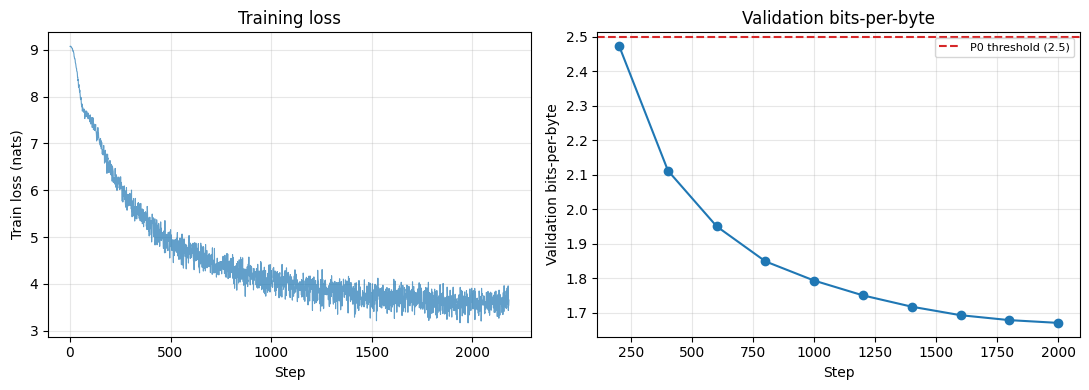

前提条件 P0(学習の進行): 最終検証 bits-per-byte = 1.6707 <= 2.5 ? OK


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
axes[0].plot(train_history["step"], train_history["train_loss"], linewidth=0.8, alpha=0.7)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Train loss (nats)")
axes[0].set_title("Training loss")
axes[0].grid(alpha=0.3)

axes[1].plot(train_history["eval_step"], train_history["eval_bits_per_byte"], marker="o")
axes[1].axhline(
    PRECONDITION_BPB_THRESHOLD,
    color="tab:red",
    linestyle="--",
    label=f"P0 threshold ({PRECONDITION_BPB_THRESHOLD})",
)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Validation bits-per-byte")
axes[1].set_title("Validation bits-per-byte")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

FINAL_EVAL_BPB = train_history["eval_bits_per_byte"][-1]
PRECONDITION_P0_OK = FINAL_EVAL_BPB <= PRECONDITION_BPB_THRESHOLD
print(
    f"前提条件 P0(学習の進行): 最終検証 bits-per-byte = {FINAL_EVAL_BPB:.4f} "
    f"<= {PRECONDITION_BPB_THRESHOLD} ? {'OK' if PRECONDITION_P0_OK else 'NG'}"
)
if SMOKE_TEST:
    print(
        "(SMOKE_TEST=True: スモークスケールでの動作確認のみが目的であり、P0 の成否は"
        "参考情報である。本番実行後にあらためて確認する。)"
    )

### 5.11 生成ヘルパー: 各デコーディング戦略での生成

温度サンプリング・top-k・top-p は 1 ステップずつ手動でループし(`generate()` は
top-k・top-p に対応しないため)、`model.forward` を直接呼び出す。貪欲法は
`model.generate(temperature=0.0)` をそのまま使う。

In [15]:
@torch.no_grad()
def generate_with_filter(
    model: GPTLanguageModel,
    prompt_ids: torch.Tensor,
    max_new_tokens: int,
    temperature: float,
    top_k: int | None = None,
    top_p: float | None = None,
    seed: int | None = None,
) -> torch.Tensor:
    """temperature サンプリングに top-k・top-p フィルタを組み合わせた生成(008)。

    ``top_k``・``top_p`` のいずれも None の場合、素の temperature サンプリングになる
    (``GPTLanguageModel.generate()`` と等価)。両方指定された場合は top-k を先に適用してから
    top-p を適用する(一般的な実装上の慣習、Holtzman et al. 2020 の実験でも同様の併用例がある)。
    """
    generator = None
    if seed is not None:
        generator = torch.Generator(device=prompt_ids.device)
        generator.manual_seed(seed)

    was_training = model.training
    model.eval()
    token_ids = prompt_ids
    try:
        for _ in range(max_new_tokens):
            context = token_ids[:, -model.max_sequence_length :]
            logits = model(context)
            next_logits = logits[:, -1, :]
            if top_k is not None:
                next_logits = top_k_filter(next_logits, top_k)
            if top_p is not None:
                next_logits = top_p_filter(next_logits, top_p)
            probs = torch.softmax(next_logits / temperature, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1, generator=generator)
            token_ids = torch.cat([token_ids, next_token], dim=1)
    finally:
        model.train(was_training)
    return token_ids


# 動作確認(較正用の小さいモデルではなく、本番学習した model で 1 回ずつ実行できることを確認)。
_probe_prompt = train_ids[:8].unsqueeze(0).to(device)
model.to(device)
_greedy_probe = model.generate(_probe_prompt.clone(), max_new_tokens=10, temperature=0.0)
_temp_probe = generate_with_filter(model, _probe_prompt.clone(), 10, temperature=1.0, seed=0)
_topk_probe = generate_with_filter(
    model, _probe_prompt.clone(), 10, temperature=1.0, top_k=40, seed=0
)
_topp_probe = generate_with_filter(
    model, _probe_prompt.clone(), 10, temperature=1.0, top_p=0.9, seed=0
)
_beam_probe = beam_search(
    model, _probe_prompt.clone(), beam_size=4, max_new_tokens=10, length_penalty=1.0
)
print("greedy:", tokenizer.decode(_greedy_probe[0].cpu())[:120])
print("temp  :", tokenizer.decode(_temp_probe[0].cpu())[:120])
print("top-k :", tokenizer.decode(_topk_probe[0].cpu())[:120])
print("top-p :", tokenizer.decode(_topp_probe[0].cpu())[:120])
print("beam  :", tokenizer.decode(_beam_probe[0][0][0].cpu())[:120])

greedy: Conjugable words (verbed by the name of the same name)
temp  : Conjugable words (verpended for the seat use) for the Dec
top-k : Conjugable words (verpended for the nativature), the name
top-p : Conjugable words (verpended for the nativature), the name
beam  : Conjugable words (verbed into the name of the same name)


### 5.12 Hugging Face Hub へのアップロード

**この節の関数は Claude Code(ローカル、第 1 段階)では呼び出さない。** `SMOKE_TEST=False`
かつ Google Colab 実行時(`IN_COLAB=True`)にのみ実際にアップロードを行うガードを設ける。
トークンの値はコード中に一切書き込まず、Google Colab の Secrets(鍵アイコン)に
`HF_TOKEN` という名前で事前に登録しておいたものを `google.colab.userdata.get("HF_TOKEN")`
で読み出す。

In [16]:
HF_REPO_ID = "kojikojiprg/ai-theories-small-gpt-en"  # アップロード先(public)


def upload_model_to_hub(model: GPTLanguageModel, tokenizer: BPEIDTokenizer, repo_id: str) -> None:
    """学習済みモデル・トークナイザ・モデルカードを Hugging Face Hub にアップロードする。

    Google Colab の Secrets に登録した HF_TOKEN を使う(トークンの値はここには書かない)。
    呼び出し前に、アップロードするアーティファクトの正しさをネットワーク呼び出しなしで
    検証しておくこと(5.13 節の state_dict ラウンドトリップ検証)。
    """
    import tempfile

    from google.colab import userdata
    from huggingface_hub import HfApi

    token = userdata.get("HF_TOKEN")
    api = HfApi(token=token)
    api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True, private=False)

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)

        torch.save(model.state_dict(), tmpdir / "model_state.pt")

        config = {
            "vocabulary_size": tokenizer.vocab_size,
            "d_model": D_MODEL,
            "num_layers": NUM_LAYERS,
            "num_heads": NUM_HEADS,
            "d_ff": D_FF,
            "swiglu_d_ff": SWIGLU_D_FF,
            "sequence_length": SEQUENCE_LENGTH,
            "dropout": DROPOUT,
            "tie_embeddings": TIE_EMBEDDINGS,
            "positional_encoding": "rope",
            "normalization": "rmsnorm",
            "feed_forward": "swiglu",
            "norm_first": True,
        }
        (tmpdir / "config.json").write_text(json.dumps(config, indent=2), encoding="utf-8")

        tokenizer_data = {
            "merges": tokenizer.bpe_tokenizer.merges,
            "vocab": sorted(tokenizer.bpe_tokenizer.vocab),
            "byte_level": tokenizer.bpe_tokenizer.byte_level,
            "chunk_split_mode": tokenizer.bpe_tokenizer.chunk_split_mode,
            "max_chunk_bytes": tokenizer.bpe_tokenizer.max_chunk_bytes,
            "symbol_to_id": tokenizer.symbol_to_id,
        }
        (tmpdir / "tokenizer.json").write_text(
            json.dumps(tokenizer_data, indent=2), encoding="utf-8"
        )

        model_card = f"""---
language: en
license: mit
tags:
- ai-theories
- gpt
- scratch-implementation
---

# ai-theories 標準小型 GPT モデル(英語)

`ai-theories`(https://github.com/kojikojiprg/ai-theories)プロジェクトの成果物。
Transformer decoder-only の GPT スタイル言語モデルを PyTorch でスクラッチ実装し、
英語 Wikipedia コーパスの一部で事前学習したもの({NUM_STEPS} ステップ、
バッチサイズ {BATCH_SIZE}、系列長 {SEQUENCE_LENGTH})。

研究・教育目的のモデルであり、品質保証は行っていない。商用・実運用での利用は想定しない。

## 関連ノートブック

- [006. 小型 GPT の事前学習](https://github.com/kojikojiprg/ai-theories/blob/main/theories/02_pretraining/006_pretraining_small_gpt.ipynb)
- [007. 学習の安定化](https://github.com/kojikojiprg/ai-theories/blob/main/theories/02_pretraining/007_training_stabilization.ipynb)
- [008. デコーディング戦略](https://github.com/kojikojiprg/ai-theories/blob/main/theories/02_pretraining/008_decoding_strategies.ipynb)

## 構成

`config.json` を参照。トークナイザはバイトレベル BPE(語彙サイズ {tokenizer.vocab_size}、
`tokenizer.json`)。
"""
        (tmpdir / "README.md").write_text(model_card, encoding="utf-8")

        api.upload_folder(repo_id=repo_id, folder_path=str(tmpdir), repo_type="model")


if not SMOKE_TEST and IN_COLAB:
    upload_model_to_hub(model, tokenizer, HF_REPO_ID)
    print(f"アップロード完了: https://huggingface.co/{HF_REPO_ID}")
else:
    print(
        "アップロードをスキップした(SMOKE_TEST=True またはローカル実行のため)。"
        "本番実行は Google Colab で SMOKE_TEST=False の状態で行うこと。"
    )

アップロード完了: https://huggingface.co/kojikojiprg/ai-theories-small-gpt-en


## 6. 不変条件のアサーション / Invariant Assertions

CLAUDE.md「不変条件のアサーション」節に従い、実験の妥当性が依存する量をすべて
アサーションで確認する。

In [17]:
# --- (1) state_dict の保存・再読み込みラウンドトリップで出力が完全一致すること(2.4 節) ---
_probe_input = train_ids[:SEQUENCE_LENGTH].unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    _logits_before = model(_probe_input).clone()

_tmp_state_path = ROOT / ".cache" / "008_roundtrip_check.pt"
torch.save(model.state_dict(), _tmp_state_path)
_reloaded_model = build_model(seed=999).to(device)  # 異なるシードで初期化した別インスタンス
_reloaded_model.load_state_dict(torch.load(_tmp_state_path, map_location=device))
_reloaded_model.eval()
with torch.no_grad():
    _logits_after = _reloaded_model(_probe_input)

assert torch.equal(_logits_before, _logits_after), "state_dict のラウンドトリップで出力が一致しない"
print("OK: state_dict 保存・再読み込みラウンドトリップで logits が完全一致")
_tmp_state_path.unlink()
del _reloaded_model, _logits_before, _logits_after

OK: state_dict 保存・再読み込みラウンドトリップで logits が完全一致


In [18]:
# --- (2) beam_search(beam_size=1) が generate() の貪欲法出力と完全一致すること ---
_bs1_prompt = train_ids[:12].unsqueeze(0).to(device)
_greedy_check = model.generate(_bs1_prompt.clone(), max_new_tokens=8, temperature=0.0)
_beam1_check = beam_search(
    model, _bs1_prompt.clone(), beam_size=1, max_new_tokens=8, length_penalty=1.0
)
assert torch.equal(_greedy_check, _beam1_check[0][0]), "beam_size=1 が貪欲法と一致しない"
print("OK: beam_search(beam_size=1) が model.generate(temperature=0.0) と完全一致")

OK: beam_search(beam_size=1) が model.generate(temperature=0.0) と完全一致


In [19]:
# --- (3) top_k_filter(k=vocab_size) がフィルタなしの元の logits と一致すること ---
_probe_logits = torch.randn(4, tokenizer.vocab_size)
_filtered_full_k = top_k_filter(_probe_logits, tokenizer.vocab_size)
assert torch.allclose(_filtered_full_k, _probe_logits), (
    "top_k_filter(k=V) が元の logits と一致しない"
)
print("OK: top_k_filter(k=vocab_size) はフィルタなしと一致")

# --- (4) top_p_filter(p=1.0) がフィルタなしの元の logits と(数値誤差の範囲で)一致すること ---
_filtered_full_p = top_p_filter(_probe_logits, 1.0)
assert torch.allclose(_filtered_full_p, _probe_logits, atol=1e-4), (
    "top_p_filter(p=1.0) が元の logits と一致しない"
)
print("OK: top_p_filter(p=1.0) はフィルタなしと(数値誤差の範囲で)一致")

OK: top_k_filter(k=vocab_size) はフィルタなしと一致
OK: top_p_filter(p=1.0) はフィルタなしと(数値誤差の範囲で)一致


In [20]:
# --- (5) トークナイザのラウンドトリップ(decode(encode(text)) == text)が成立すること ---
# 5.6 節で既に検証済みだが、独立した検証テキスト(学習コーパスの別の範囲)で再確認する。
_roundtrip_sample_2 = (
    train_text[100_000 : 100_000 + 20_000] if len(train_text) > 120_000 else train_text
)
assert bpe_tokenizer.decode(bpe_tokenizer.encode(_roundtrip_sample_2)) == _roundtrip_sample_2
print(f"OK: トークナイザのラウンドトリップ一致(独立サンプル、{len(_roundtrip_sample_2):,} 文字)")

OK: トークナイザのラウンドトリップ一致(独立サンプル、20,000 文字)


In [21]:
# --- (6) compute_ngram_repetition_rate が完全反復系列で高い値・完全ユニーク系列で 0 になること ---
_repeated_seq = [1, 2, 3, 1, 2, 3, 1, 2, 3]
_unique_seq = [1, 2, 3, 4, 5, 6, 7, 8, 9]
_rep_repeated = compute_ngram_repetition_rate(_repeated_seq, n=3)
_rep_unique = compute_ngram_repetition_rate(_unique_seq, n=3)
assert _rep_unique == 0.0, f"完全ユニーク系列の重複率が 0 でない: {_rep_unique}"
assert _rep_repeated > 0.5, f"完全反復系列の重複率が十分に高くない: {_rep_repeated}"
print(
    f"OK: compute_ngram_repetition_rate(完全反復)={_rep_repeated:.4f}, "
    f"compute_ngram_repetition_rate(完全ユニーク)={_rep_unique:.4f}"
)

OK: compute_ngram_repetition_rate(完全反復)=0.5714, compute_ngram_repetition_rate(完全ユニーク)=0.0000


## 7. 実験 / Experiments

CLAUDE.md「1 実験 = 1 検証事項」規約により、実験 A(退化現象)・実験 B(top-k と
top-p の適応性の違い)を主軸(三値判定を厳密に適用)、実験 C(temperature のトレード
オフ)・実験 D(beam size のトレードオフ)を補助(定性的な観察、判定基準を設けない)
とする。

### 7.1 生成実験の共通設定

プロンプト・生成長・シード数は本番実行前に(結果を見る前に)ここで宣言する。

In [22]:
if SMOKE_TEST:
    N_PROMPTS = 4
    PROMPT_LENGTH = 12
    GEN_LENGTH = 24
    N_SEEDS_STOCHASTIC = 3
else:
    N_PROMPTS = 8
    PROMPT_LENGTH = 24
    GEN_LENGTH = 64
    N_SEEDS_STOCHASTIC = 5

REP_N = 4  # n-gram 重複率の n(Holtzman et al. 2020 の rep-4 慣習)
DISTINCT_N = 3  # distinct-n の n
BEAM_SIZE_MAIN = 4  # 実験 A で使うビームサーチのビーム数
TOP_P_MAIN = 0.9  # 実験 A・B で使う top-p の p
TOP_K_MAIN = 40  # 実験 B の診断で使う top-k の k
TEMPERATURE_MAIN = 1.0  # 実験 A で使う temperature サンプリングの温度

# 検証テキストからプロンプトを均等な間隔で切り出す(乱数に依存させず再現性を持たせる)。
_val_len = val_ids.size(0)
_stride = max(1, (_val_len - PROMPT_LENGTH - GEN_LENGTH) // N_PROMPTS)
prompt_ids_list = [
    val_ids[i * _stride : i * _stride + PROMPT_LENGTH].unsqueeze(0).to(device)
    for i in range(N_PROMPTS)
    if i * _stride + PROMPT_LENGTH <= _val_len
]
N_PROMPTS = len(prompt_ids_list)  # 端数により減った場合はここで確定させる
print(
    f"N_PROMPTS={N_PROMPTS}, PROMPT_LENGTH={PROMPT_LENGTH}, GEN_LENGTH={GEN_LENGTH}, "
    f"N_SEEDS_STOCHASTIC={N_SEEDS_STOCHASTIC}"
)
print(
    f"REP_N={REP_N}, DISTINCT_N={DISTINCT_N}, BEAM_SIZE_MAIN={BEAM_SIZE_MAIN}, "
    f"TOP_P_MAIN={TOP_P_MAIN}, TOP_K_MAIN={TOP_K_MAIN}, TEMPERATURE_MAIN={TEMPERATURE_MAIN}"
)

N_PROMPTS=8, PROMPT_LENGTH=24, GEN_LENGTH=64, N_SEEDS_STOCHASTIC=5
REP_N=4, DISTINCT_N=3, BEAM_SIZE_MAIN=4, TOP_P_MAIN=0.9, TOP_K_MAIN=40, TEMPERATURE_MAIN=1.0


### 7.2 実験宣言セル: 検証すること・判定基準

**共通の対比量・標準偏差の導出(実験 A・B で共通)**: グループ A・グループ B をそれぞれ
$n_A$・$n_B$ 個のサンプル(実験 A ではプロンプト x 手法の組、実験 B ではプロンプトごとの
相関係数)で測定し、標本平均 $\bar{x}_A, \bar{x}_B$・標本標準偏差 $s_A, s_B$
(不偏標準偏差、`ddof=1`)を求める。

$$
\Delta = \bar{x}_B - \bar{x}_A \qquad \mathrm{SE}(\Delta) = \sqrt{\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}}
\qquad \text{閾値} = 2 \times \mathrm{SE}(\Delta)
$$

判定は **支持**($\Delta$ が期待方向に閾値超え)/ **反証**($\Delta$ が逆方向に閾値超え)/
**判定不能**($|\Delta| \le$ 閾値)の 3 分岐とする(007 6.2 節・6.4 節と同一の方式)。

| # | 実験 | 対比条件(B vs A) | 対比量 | 期待方向 |
|---|---|---|---|---|
| A | 退化現象 | {temperature, top-p}(B) vs {貪欲法, beam}(A) | REP_N-gram 重複率 | $\Delta < 0$(B の方が低い) |
| B | top-k/top-p の適応性 | 実測相関係数(B) vs ゼロ基準(A、全要素 0) | エントロピーと top-p 候補集合サイズの相関係数 | $\Delta > 0$(正の相関) |

**実験 A の対比量の直接性について**: 検証したい介入(デコーディング戦略の違い)が
直接作用するのは各ステップでの「候補集合の絞り込み方」であり、n-gram 重複率は
その結果として系列全体に現れる下流の量である。3.4 節の理論(退化現象は繰り返し
ループへの自己強化的な収束として説明される)に従えば、n-gram 重複率(特に短い n)は
繰り返しループの直接の観測量に近く、両者の間に他の要因が介在しにくいため、対比量として
採用する(Holtzman et al., 2020 自身も rep-n を主要な定量指標として用いている)。

**実験 B の対比量の直接性について**: 検証したい性質(top-p の候補集合サイズがエントロピーに
応じて動的に変化すること)そのものを対比量(相関係数)として直接測定しており、介入の
作用点との乖離はない。

**前提条件(pre-condition)**: 判定基準とは別に、検証したい仮説とは独立な量として
本番実行の前に宣言する。

- **前提条件 P0(学習の進行、5.10 節で確定済み)**: 最終検証 bits-per-byte が
  `PRECONDITION_BPB_THRESHOLD` 以下であること。実験 A・B の両方に共通して適用する
  (モデルが十分に流暢なテキストを生成できないと、退化現象の比較(実験 A)も
  分布の形状に基づく適応性の比較(実験 B)も意味を持たない)。
- **前提条件 P1(分布の非退化、実験 B のみ)**: 各プロンプトのエントロピー系列
  (`GEN_LENGTH` ステップ分)の標準偏差が `PRECONDITION_ENTROPY_STD_MIN` を超えること。
  エントロピーが全ステップで一定であれば、エントロピーと候補集合サイズの相関係数は
  定義上不安定になり(分散 0 の変数との相関)、「適応性がない」ことの証拠にはならない
  (適応性を測る前提として、そもそもエントロピー自体に変動が必要という、検証したい
  仮説(top-p が適応的かどうか)とは独立な条件)。

In [23]:
PRECONDITION_ENTROPY_STD_MIN = 0.05  # 前提条件 P1 の採用閾値(本番実行前に宣言、結果非依存)

### 7.3 判定関数

In [24]:
def judge_three_way(delta: float, threshold: float, expect_positive: bool) -> str:
    """7.2 節の共通公式による 3 分岐判定(007 6.4 節と同一の実装)。"""
    if expect_positive:
        if delta > threshold:
            return "支持"
        elif delta < -threshold:
            return "反証"
        return "判定不能"
    else:
        if delta < -threshold:
            return "支持"
        elif delta > threshold:
            return "反証"
        return "判定不能"


def contrast_stats(values_a, values_b) -> dict:
    a, b = np.asarray(values_a, dtype=float), np.asarray(values_b, dtype=float)
    mean_a, mean_b = a.mean(), b.mean()
    std_a = a.std(ddof=1) if len(a) > 1 else 0.0
    std_b = b.std(ddof=1) if len(b) > 1 else 0.0
    delta = mean_b - mean_a
    se = float(np.sqrt(std_a**2 / len(a) + std_b**2 / len(b)))
    return {
        "mean_a": float(mean_a),
        "mean_b": float(mean_b),
        "std_a": float(std_a),
        "std_b": float(std_b),
        "n_a": len(a),
        "n_b": len(b),
        "delta": float(delta),
        "se": se,
        "threshold": 2 * se,
    }


def judge_with_precondition(precondition_ok: bool, judge_fn, *args) -> tuple[str, dict | None]:
    """前提条件が成立している場合のみ judge_fn を呼ぶ(007 6.4 節と同一の実装)。"""
    if not precondition_ok:
        return "前提不成立", None
    return judge_fn(*args)


def judge_experiment_a(values_deterministic, values_stochastic) -> tuple[str, dict]:
    s = contrast_stats(values_deterministic, values_stochastic)
    return judge_three_way(s["delta"], s["threshold"], expect_positive=False), s


def judge_experiment_b(values_zero_baseline, values_correlation) -> tuple[str, dict]:
    s = contrast_stats(values_zero_baseline, values_correlation)
    return judge_three_way(s["delta"], s["threshold"], expect_positive=True), s


# --- 4 分岐到達性の確認(ダミー入力、本番データを使う前に実施) ---
_dummy_a = [1.0, 1.02, 0.98]
_dummy_cases = {
    "delta明確に正": [3.0, 3.05, 2.95],
    "delta明確に負": [-1.0, -0.95, -1.05],
    "deltaゼロ近辺": [1.0, 1.03, 0.97],
}
for _name, _judge_fn in {
    "experiment_a": judge_experiment_a,
    "experiment_b": judge_experiment_b,
}.items():
    _reached = set()
    for _case_name, _dummy_b in _dummy_cases.items():
        _verdict, _ = judge_with_precondition(True, _judge_fn, _dummy_a, _dummy_b)
        _reached.add(_verdict)
    print(f"{_name}(前提成立): 到達した判定 = {sorted(_reached)}")
    assert _reached == {"支持", "反証", "判定不能"}, (
        f"{_name} が 3 分岐すべてに到達しない: {_reached}"
    )
    _verdict_np, _stats_np = judge_with_precondition(
        False, _judge_fn, _dummy_a, _dummy_cases["delta明確に正"]
    )
    assert _verdict_np == "前提不成立" and _stats_np is None
print("OK: 実験 A・B の判定関数が、支持 / 反証 / 判定不能 / 前提不成立の 4 分岐すべてに到達する")

experiment_a(前提成立): 到達した判定 = ['判定不能', '反証', '支持']
experiment_b(前提成立): 到達した判定 = ['判定不能', '反証', '支持']
OK: 実験 A・B の判定関数が、支持 / 反証 / 判定不能 / 前提不成立の 4 分岐すべてに到達する


### 7.4 実験 A: 退化現象(Degeneration)の検証

貪欲法・ビームサーチ(グループ A、決定的)と temperature サンプリング・top-p
サンプリング(グループ B、確率的)で、各プロンプトから生成した継続テキストの
REP_N-gram 重複率を比較する。グループ A はプロンプトごとに 1 サンプル(貪欲法・
ビームサーチそれぞれ)、グループ B はプロンプト x シードごとに 1 サンプル
(temperature・top-p それぞれ)を生成する。

In [25]:
def generate_all_methods_for_prompt(prompt: torch.Tensor) -> dict[str, list[torch.Tensor]]:
    """1 プロンプトについて、実験 A で使う全手法の生成トークン列(新規生成分のみ)を返す。"""
    results: dict[str, list[torch.Tensor]] = {
        "greedy": [],
        "beam": [],
        "temperature": [],
        "top_p": [],
    }

    greedy_out = model.generate(prompt.clone(), max_new_tokens=GEN_LENGTH, temperature=0.0)
    results["greedy"].append(greedy_out[0, prompt.size(1) :].cpu())

    beam_out = beam_search(
        model,
        prompt.clone(),
        beam_size=BEAM_SIZE_MAIN,
        max_new_tokens=GEN_LENGTH,
        length_penalty=1.0,
    )
    best_beam_seq = beam_out[0][0]
    results["beam"].append(best_beam_seq[0, prompt.size(1) :].cpu())

    for seed in range(N_SEEDS_STOCHASTIC):
        temp_out = generate_with_filter(
            model, prompt.clone(), GEN_LENGTH, temperature=TEMPERATURE_MAIN, seed=seed
        )
        results["temperature"].append(temp_out[0, prompt.size(1) :].cpu())

        topp_out = generate_with_filter(
            model, prompt.clone(), GEN_LENGTH, temperature=1.0, top_p=TOP_P_MAIN, seed=seed
        )
        results["top_p"].append(topp_out[0, prompt.size(1) :].cpu())

    return results


experiment_a_generations = [generate_all_methods_for_prompt(p) for p in prompt_ids_list]

rep_rates_deterministic = []  # greedy + beam, プロンプトごと
rep_rates_stochastic = []  # temperature + top_p, プロンプト x シードごと
for gen in experiment_a_generations:
    rep_rates_deterministic.append(compute_ngram_repetition_rate(gen["greedy"][0], REP_N))
    rep_rates_deterministic.append(compute_ngram_repetition_rate(gen["beam"][0], REP_N))
    for seq in gen["temperature"]:
        rep_rates_stochastic.append(compute_ngram_repetition_rate(seq, REP_N))
    for seq in gen["top_p"]:
        rep_rates_stochastic.append(compute_ngram_repetition_rate(seq, REP_N))

_std_det = np.std(rep_rates_deterministic, ddof=1)
_std_sto = np.std(rep_rates_stochastic, ddof=1)
print(
    f"グループ A(貪欲法・beam、n={len(rep_rates_deterministic)}): "
    f"mean={np.mean(rep_rates_deterministic):.4f}, std={_std_det:.4f}"
)
print(
    f"グループ B(temperature・top-p、n={len(rep_rates_stochastic)}): "
    f"mean={np.mean(rep_rates_stochastic):.4f}, std={_std_sto:.4f}"
)

グループ A(貪欲法・beam、n=16): mean=0.5205, std=0.2101
グループ B(temperature・top-p、n=80): mean=0.0002, std=0.0018


In [26]:
# 実験 A の判定コード(実装・実行するが、判定結果を結論として本文には書かない。8 節参照)。
verdict_a, stats_a = judge_with_precondition(
    PRECONDITION_P0_OK, judge_experiment_a, rep_rates_deterministic, rep_rates_stochastic
)
print(f"実験 A: 判定 = {verdict_a}")
if stats_a is not None:
    print(
        f"  delta={stats_a['delta']:.4f}, threshold={stats_a['threshold']:.4f}, "
        f"mean_a={stats_a['mean_a']:.4f}, mean_b={stats_a['mean_b']:.4f}"
    )

実験 A: 判定 = 支持
  delta=-0.5203, threshold=0.1050, mean_a=0.5205, mean_b=0.0002


### 7.5 実験 B: top-k と top-p の適応性の違い

各プロンプトについて貪欲法で `GEN_LENGTH` ステップ生成する軌道に沿って、各ステップの
分布のエントロピーと、その分布に `top_p_filter(p=TOP_P_MAIN)` を適用したときの
候補集合サイズ(有限の logits を持つ要素数)を記録する。プロンプトごとに、
エントロピー系列と候補集合サイズ系列の間のピアソン相関係数を計算する
(プロンプト = 1 サンプルとして扱う)。診断として、`top_k_filter(k=TOP_K_MAIN)` の
候補集合サイズが全ステップで定数 `TOP_K_MAIN` に一致することも確認する。

In [27]:
@torch.no_grad()
def trace_entropy_and_nucleus_size(prompt: torch.Tensor) -> dict[str, np.ndarray]:
    """貪欲法の生成軌道に沿って、各ステップのエントロピー・top-p 候補集合サイズ・
    top-k 候補集合サイズを記録する(実験 B)。"""
    entropies, topp_sizes, topk_sizes = [], [], []
    token_ids = prompt.clone()
    was_training = model.training
    model.eval()
    for _ in range(GEN_LENGTH):
        context = token_ids[:, -model.max_sequence_length :]
        logits = model(context)[:, -1, :]  # (1, V)
        probs = torch.softmax(logits, dim=-1)
        entropy = -(probs * torch.log(probs.clamp_min(1e-12))).sum(dim=-1).item()
        entropies.append(entropy)

        filtered_p = top_p_filter(logits, TOP_P_MAIN)
        topp_sizes.append(int(torch.isfinite(filtered_p).sum().item()))

        filtered_k = top_k_filter(logits, TOP_K_MAIN)
        topk_sizes.append(int(torch.isfinite(filtered_k).sum().item()))

        next_token = logits.argmax(dim=-1, keepdim=True)
        token_ids = torch.cat([token_ids, next_token], dim=1)
    model.train(was_training)
    return {
        "entropy": np.array(entropies),
        "topp_size": np.array(topp_sizes),
        "topk_size": np.array(topk_sizes),
    }


experiment_b_traces = [trace_entropy_and_nucleus_size(p) for p in prompt_ids_list]

correlations_topp = []
entropy_stds = []
topk_size_all = []
for trace in experiment_b_traces:
    entropy_stds.append(float(np.std(trace["entropy"], ddof=1)))
    if np.std(trace["entropy"]) > 0 and np.std(trace["topp_size"]) > 0:
        r = float(np.corrcoef(trace["entropy"], trace["topp_size"])[0, 1])
    else:
        r = 0.0
    correlations_topp.append(r)
    topk_size_all.extend(trace["topk_size"].tolist())

print(
    f"プロンプトごとの相関係数(entropy vs top-p 候補集合サイズ): "
    f"{[round(r, 3) for r in correlations_topp]}"
)
print(f"エントロピー系列の標準偏差(プロンプトごと): {[round(s, 4) for s in entropy_stds]}")
print(
    f"top-k 候補集合サイズ(全ステップ x 全プロンプト、診断): "
    f"min={min(topk_size_all)}, max={max(topk_size_all)}(TOP_K_MAIN={TOP_K_MAIN} と一致するはず)"
)
assert all(s == TOP_K_MAIN for s in topk_size_all), "top-k 候補集合サイズが固定値と一致しない"
print("OK: top-k 候補集合サイズは全ステップで定数(TOP_K_MAIN)に一致(=非適応性の直接確認)")

プロンプトごとの相関係数(entropy vs top-p 候補集合サイズ): [0.837, 0.864, 0.856, 0.854, 0.589, 0.878, 0.919, 0.89]
エントロピー系列の標準偏差(プロンプトごと): [1.5828, 1.5677, 1.6034, 1.6881, 1.0812, 0.8966, 0.9856, 1.8494]
top-k 候補集合サイズ(全ステップ x 全プロンプト、診断): min=40, max=40(TOP_K_MAIN=40 と一致するはず)
OK: top-k 候補集合サイズは全ステップで定数(TOP_K_MAIN)に一致(=非適応性の直接確認)


In [28]:
PRECONDITION_P1_OK = all(s > PRECONDITION_ENTROPY_STD_MIN for s in entropy_stds)
print(
    f"前提条件 P1(分布の非退化): 全プロンプトのエントロピー標準偏差 > "
    f"{PRECONDITION_ENTROPY_STD_MIN} ? {'OK' if PRECONDITION_P1_OK else 'NG'}"
)
PRECONDITION_B_OK = PRECONDITION_P0_OK and PRECONDITION_P1_OK

# 実験 B の判定コード(実装・実行するが、判定結果を結論として本文には書かない。8 節参照)。
_zero_baseline = [0.0] * len(correlations_topp)
verdict_b, stats_b = judge_with_precondition(
    PRECONDITION_B_OK, judge_experiment_b, _zero_baseline, correlations_topp
)
print(f"実験 B: 判定 = {verdict_b}")
if stats_b is not None:
    print(f"  delta(=mean相関係数)={stats_b['delta']:.4f}, threshold={stats_b['threshold']:.4f}")

前提条件 P1(分布の非退化): 全プロンプトのエントロピー標準偏差 > 0.05 ? OK
実験 B: 判定 = 支持
  delta(=mean相関係数)=0.8358, threshold=0.0726


### 7.6 可視化: 実験 A・B

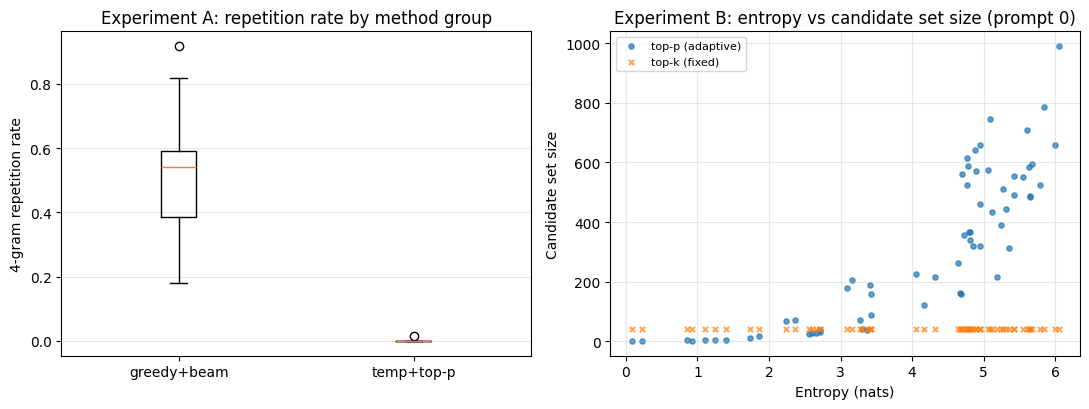

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].boxplot(
    [rep_rates_deterministic, rep_rates_stochastic], tick_labels=["greedy+beam", "temp+top-p"]
)
axes[0].set_ylabel(f"{REP_N}-gram repetition rate")
axes[0].set_title("Experiment A: repetition rate by method group")
axes[0].grid(alpha=0.3, axis="y")

_trace0 = experiment_b_traces[0]
axes[1].scatter(_trace0["entropy"], _trace0["topp_size"], s=14, alpha=0.7, label="top-p (adaptive)")
axes[1].scatter(
    _trace0["entropy"], _trace0["topk_size"], s=14, alpha=0.7, marker="x", label="top-k (fixed)"
)
axes[1].set_xlabel("Entropy (nats)")
axes[1].set_ylabel("Candidate set size")
axes[1].set_title("Experiment B: entropy vs candidate set size (prompt 0)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

### 7.7 実験 C(補助): temperature による多様性と一貫性のトレードオフ

**判定基準は設けない(定性的な観察のみである)。** temperature を等比刻みで複数水準
振り、各水準で生成したテキストの distinct-n(多様性)と、生成テキストを学習済み
モデル自身で評価した bits-per-byte 相当の指標(生成トークン列に対する平均負の対数
尤度、一貫性の代理指標)を観察する。

In [30]:
TEMPERATURES = [0.5, 0.7, 1.0, 1.4, 2.0]  # 公比約 1.4 の等比刻み

experiment_c_results = {"temperature": [], "distinct_n_mean": [], "self_nll_mean": []}
for temperature in TEMPERATURES:
    distinct_ns, self_nlls = [], []
    for prompt in prompt_ids_list:
        for seed in range(N_SEEDS_STOCHASTIC):
            out = generate_with_filter(
                model, prompt.clone(), GEN_LENGTH, temperature=temperature, seed=seed
            )
            new_tokens = out[0, prompt.size(1) :]
            distinct_ns.append(compute_distinct_n(new_tokens.cpu(), DISTINCT_N))

            with torch.no_grad():
                context_for_eval = out[:, :-1]
                logits = model(context_for_eval[:, -model.max_sequence_length :])
                target = out[:, -new_tokens.size(0) :]
                nll = torch.nn.functional.cross_entropy(
                    logits[:, -new_tokens.size(0) :, :].reshape(-1, tokenizer.vocab_size),
                    target.reshape(-1),
                )
                self_nlls.append(nll.item())

    experiment_c_results["temperature"].append(temperature)
    experiment_c_results["distinct_n_mean"].append(float(np.mean(distinct_ns)))
    experiment_c_results["self_nll_mean"].append(float(np.mean(self_nlls)))
    print(
        f"T={temperature}: distinct-{DISTINCT_N}(mean)={np.mean(distinct_ns):.4f}, "
        f"self-NLL(mean, nats)={np.mean(self_nlls):.4f}"
    )

T=0.5: distinct-3(mean)=0.9194, self-NLL(mean, nats)=2.1466
T=0.7: distinct-3(mean)=0.9742, self-NLL(mean, nats)=2.7501
T=1.0: distinct-3(mean)=0.9988, self-NLL(mean, nats)=4.3752
T=1.4: distinct-3(mean)=1.0000, self-NLL(mean, nats)=6.7058
T=2.0: distinct-3(mean)=1.0000, self-NLL(mean, nats)=9.4008


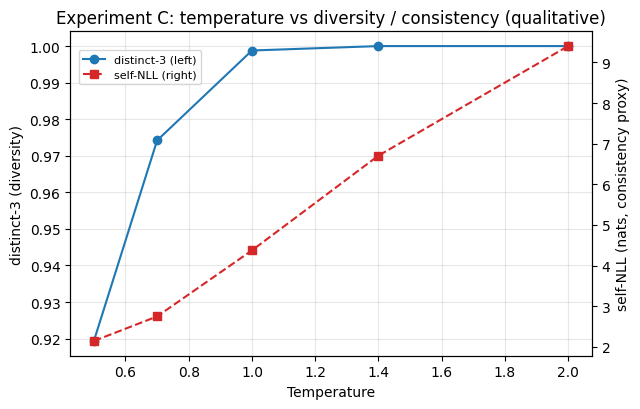

In [31]:
fig, ax1 = plt.subplots(figsize=(6.5, 4.2))
ax2 = ax1.twinx()
ax1.plot(
    experiment_c_results["temperature"],
    experiment_c_results["distinct_n_mean"],
    "o-",
    color="tab:blue",
    label=f"distinct-{DISTINCT_N} (left)",
)
ax2.plot(
    experiment_c_results["temperature"],
    experiment_c_results["self_nll_mean"],
    "s--",
    color="tab:red",
    label="self-NLL (right)",
)
ax1.set_xlabel("Temperature")
ax1.set_ylabel(f"distinct-{DISTINCT_N} (diversity)")
ax2.set_ylabel("self-NLL (nats, consistency proxy)")
ax1.set_title("Experiment C: temperature vs diversity / consistency (qualitative)")
ax1.grid(alpha=0.3)
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88), fontsize=8)
fig.tight_layout()
plt.show()

### 7.8 実験 D(補助): beam size と生成確率・多様性のトレードオフ

**判定基準は設けない(定性的な観察のみである)。** beam size を公比 2 の等比刻みで
複数水準振り、各水準で best 候補の長さ正規化対数尤度(スコア)と、最終ビーム内候補間の
多様性(候補どうしを連結した系列の distinct-n、値が低いほど候補間で似た系列が多い)を
観察する。

In [32]:
BEAM_SIZES = [1, 2, 4, 8]  # 公比 2 の等比刻み

experiment_d_results = {"beam_size": [], "best_score_mean": [], "beam_diversity_mean": []}
for beam_size in BEAM_SIZES:
    best_scores, diversities = [], []
    for prompt in prompt_ids_list:
        beams = beam_search(
            model,
            prompt.clone(),
            beam_size=beam_size,
            max_new_tokens=GEN_LENGTH,
            length_penalty=1.0,
        )
        best_scores.append(beams[0][1])  # 正規化済み対数尤度(降順ソート済みの先頭が best)

        if beam_size > 1:
            concatenated = torch.cat([seq[0, prompt.size(1) :] for seq, _ in beams]).cpu()
            diversities.append(compute_distinct_n(concatenated, DISTINCT_N))
        else:
            diversities.append(float("nan"))  # beam_size=1 では候補間多様性は定義できない

    diversity_mean = float(np.mean(diversities)) if beam_size > 1 else float("nan")
    experiment_d_results["beam_size"].append(beam_size)
    experiment_d_results["best_score_mean"].append(float(np.mean(best_scores)))
    experiment_d_results["beam_diversity_mean"].append(diversity_mean)
    _diversity_str = f"{diversity_mean:.4f}" if beam_size > 1 else "N/A(beam_size=1)"
    print(
        f"beam_size={beam_size}: best_score(mean)={np.mean(best_scores):.4f}, "
        f"beam内distinct-{DISTINCT_N}(mean)={_diversity_str}"
    )

beam_size=1: best_score(mean)=-6.3028, beam内distinct-3(mean)=N/A(beam_size=1)
beam_size=2: best_score(mean)=-6.0012, beam内distinct-3(mean)=0.2440
beam_size=4: best_score(mean)=-5.8373, beam内distinct-3(mean)=0.1447
beam_size=8: best_score(mean)=-5.0329, beam内distinct-3(mean)=0.0868


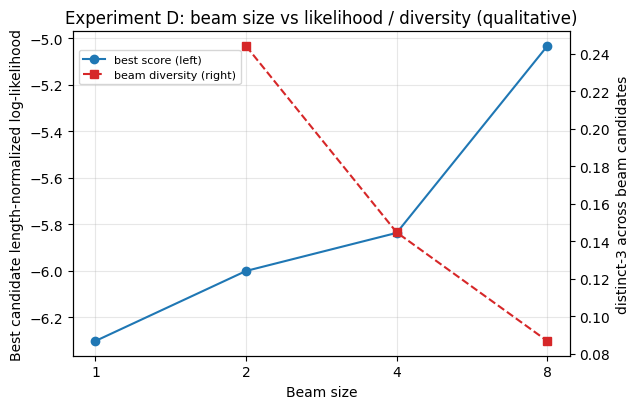

In [33]:
fig, ax1 = plt.subplots(figsize=(6.5, 4.2))
ax2 = ax1.twinx()
ax1.plot(
    experiment_d_results["beam_size"],
    experiment_d_results["best_score_mean"],
    "o-",
    color="tab:blue",
    label="best score (left)",
)
ax2.plot(
    experiment_d_results["beam_size"][1:],
    experiment_d_results["beam_diversity_mean"][1:],
    "s--",
    color="tab:red",
    label="beam diversity (right)",
)
ax1.set_xscale("log", base=2)
ax1.set_xticks(BEAM_SIZES)
ax1.set_xticklabels(BEAM_SIZES)
ax1.set_xlabel("Beam size")
ax1.set_ylabel("Best candidate length-normalized log-likelihood")
ax2.set_ylabel(f"distinct-{DISTINCT_N} across beam candidates")
ax1.set_title("Experiment D: beam size vs likelihood / diversity (qualitative)")
ax1.grid(alpha=0.3)
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88), fontsize=8)
fig.tight_layout()
plt.show()

## 8. 結果・考察 / Results and Discussion

**この節は第 1 段階(Claude Code、ローカル・スモークテスト実行)では本文を書かない**
(CLAUDE.md「Colab 実行を伴うノートブックの二段階運用」節)。本番実行(Google Colab、
`SMOKE_TEST=False`)の実際のセル出力と突き合わせたうえで、こうじさんが第 3 段階として
以下の内容を追記する。

### 8.1 モデル学習(5.10 節)

- 検証 bits-per-byte の学習曲線の推移(発散していないことの確認)
- 前提条件 P0(最終検証 bits-per-byte が `PRECONDITION_BPB_THRESHOLD` 以下か)の成否
- 較正で採用した学習率・gradient clipping 閾値の実測値

### 8.2 実験 A: 退化現象

- グループ A(貪欲法・ビームサーチ)・グループ B(temperature・top-p)の
  REP_N-gram 重複率の実測平均・標準偏差
- 前提条件 P0 の成否、判定(支持 / 反証 / 判定不能 / 前提不成立)の結果
- 生成例の抜粋(繰り返しパターンが実際に観察されるか、定性的な観察)

### 8.3 実験 B: top-k と top-p の適応性の違い

- プロンプトごとの相関係数(エントロピー vs top-p 候補集合サイズ)の実測値
- 前提条件 P0・P1 の成否、判定の結果
- エントロピーと候補集合サイズの散布図から読み取れる傾向(定性的な考察)

### 8.4 実験 C: temperature による多様性と一貫性のトレードオフ(定性)

- temperature を上げたときの distinct-n・self-NLL の推移が理論的な予想
  (多様性は単調増加、一貫性の代理指標は悪化)と整合するかの観察
- 判定基準は設けていないため、結論としては書かず観察として記述する

### 8.5 実験 D: beam size と生成確率・多様性のトレードオフ(定性)

- beam size を増やしたときの best 候補スコア・beam 内多様性の推移の観察
- 判定基準は設けていないため、結論としては書かず観察として記述する

### 8.6 Hugging Face Hub へのアップロード

- アップロード先(`kojikojiprg/ai-theories-small-gpt-en`)のリンク
- アップロード前の不変条件アサーション(state_dict ラウンドトリップ)が本番モデルでも
  成立したことの確認